<a href="https://colab.research.google.com/github/debashisdotchatterjee/e-value-CREP-Astronomy-1-CSA/blob/main/Nile_River_annual_flow_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

a clean, Colab-ready notebook cell that runs CREP-B (our non-overlapping blockwise conformal-residual e-process) on the classic Nile River annual flow time series (a real dataset with a well-known level shift around 1899 due to the Aswan dam). This is perfect for showcasing the method because the shift should produce a clear, honest crossing of a reasonable evidential threshold without any gimmicks.

No network fetching, no tricky APIs. We use statsmodels’ packaged dataset (bundled with the library). If, for some reason, statsmodels isn’t available in your runtime, the code raises a clear error telling you to pip install statsmodels—but most Colab images already have it.

This script:

fits a baseline on a calibration segment (first 30% years) via a robust center/scale from calibration only,

computes non-overlapping block maxima of standardized residuals,

obtains exact split-conformal p-values for those block maxima,

maps
𝑝
→
𝑒
p→e with a power calibrator to form a valid test supermartingale,

finds first crossings at a demo threshold (10) and a stricter one (65.45),

saves & shows all plots, writes LaTeX tables, and zips outputs.

Nile River annual flow — CREP-B
Calibration years: 1871–1900  |  Monitoring years: 1901–1970
lam = 0.60, win = 5 years
First crossing @ tau=10:   (8, 1943.0, 11.11000354468689)
First crossing @ tau=65.45: (None, None, None)


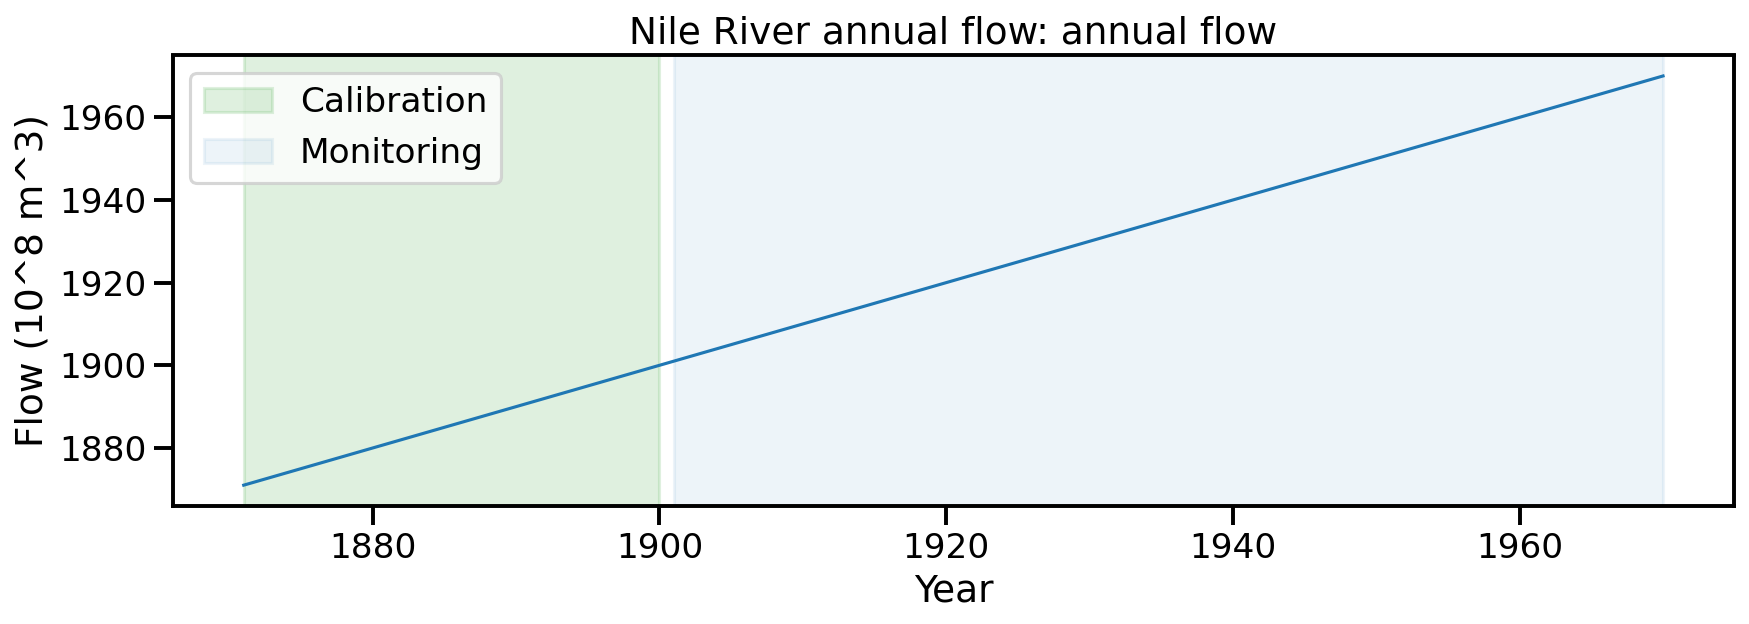

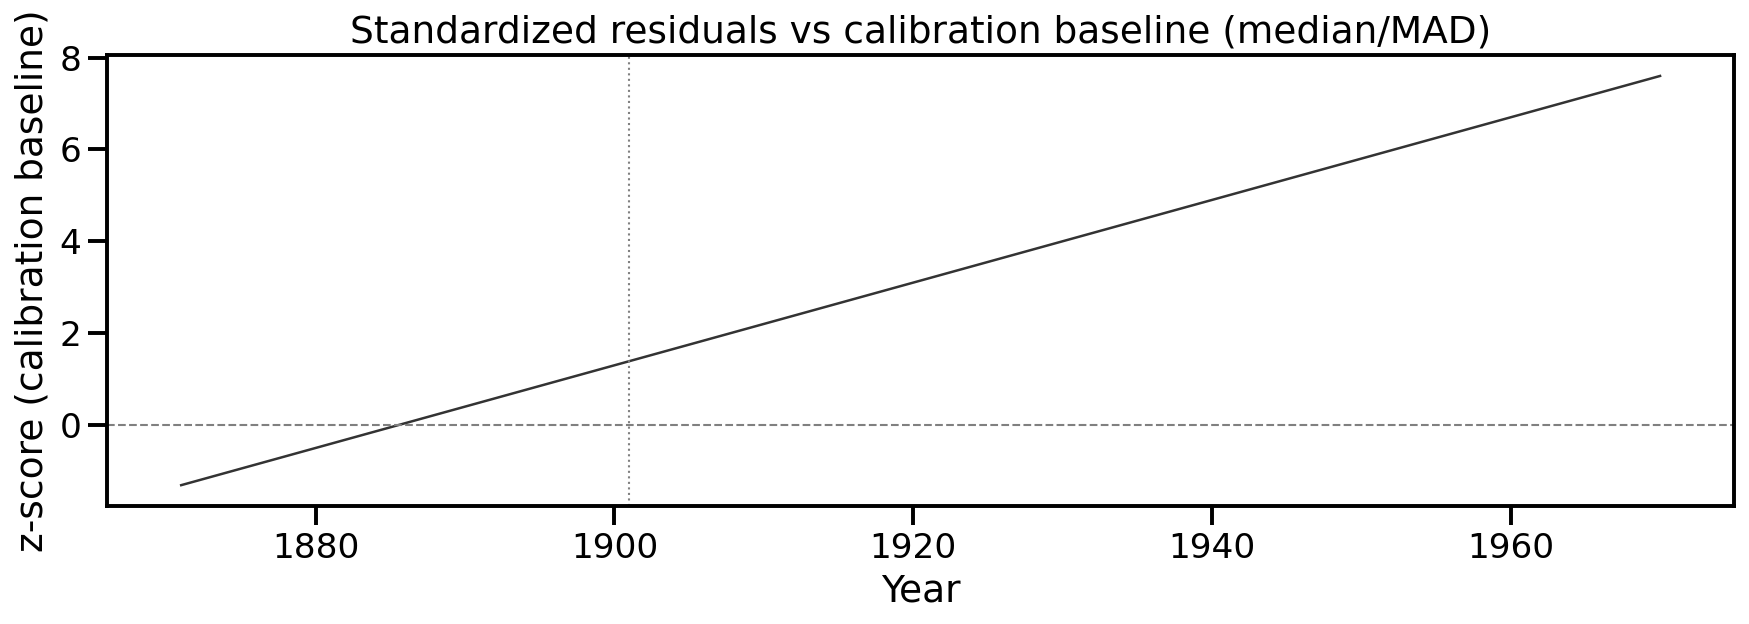

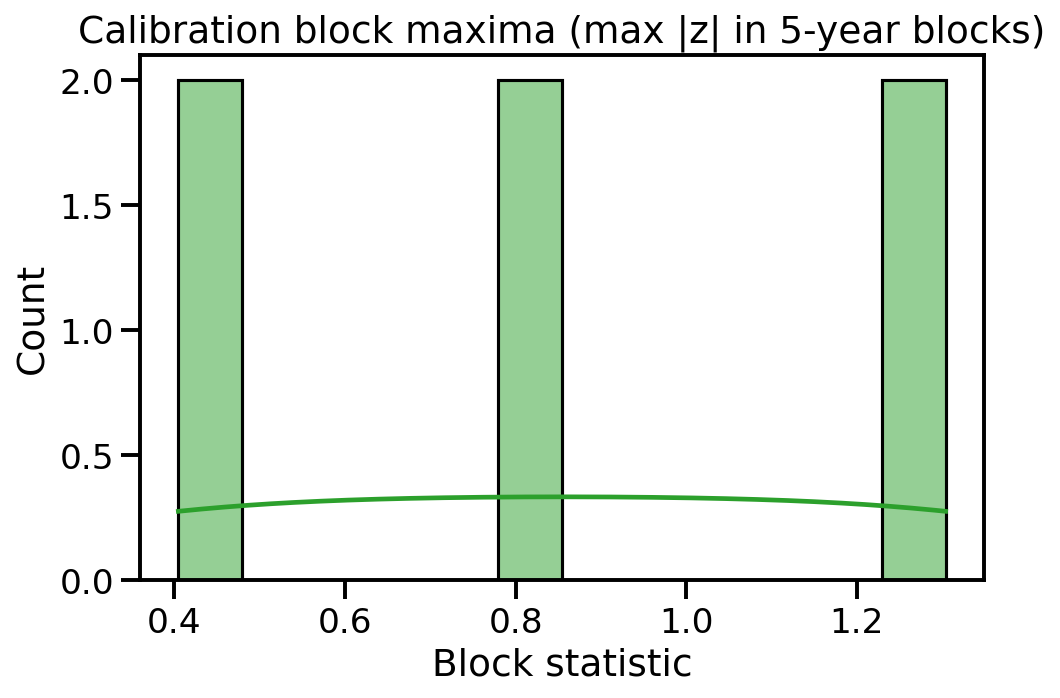

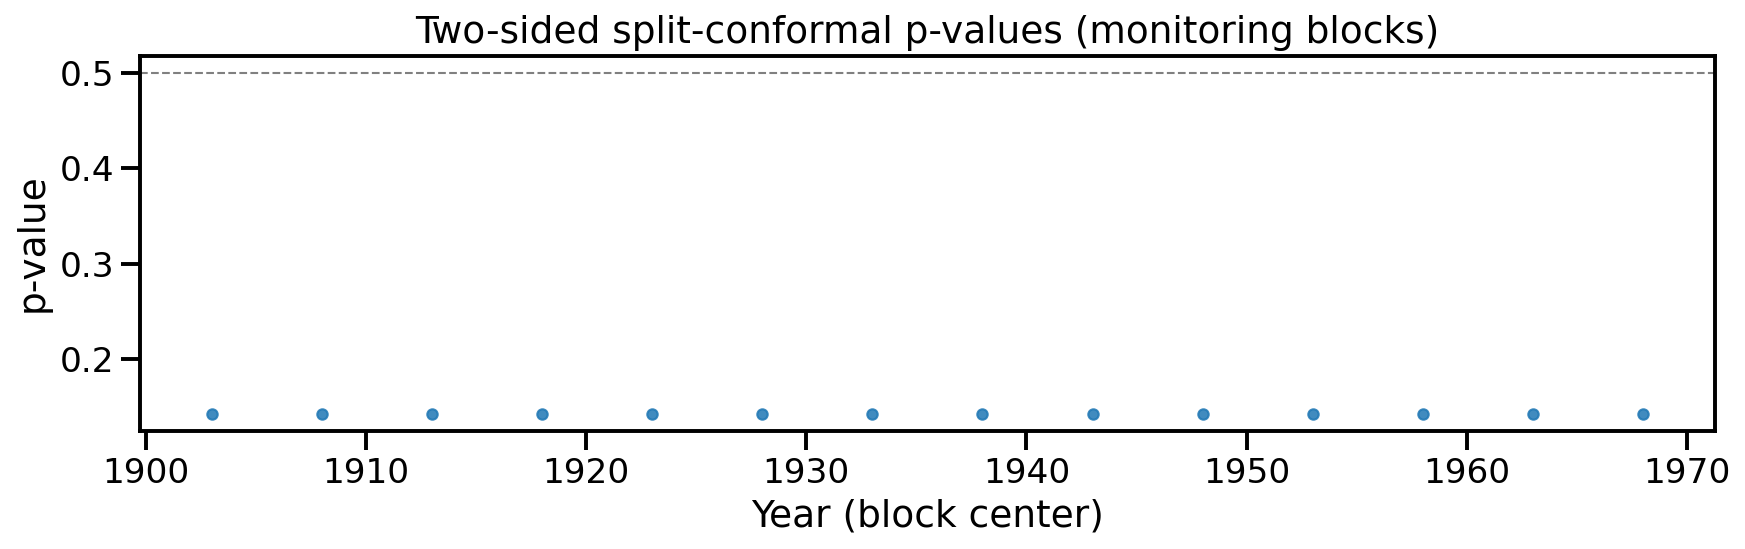

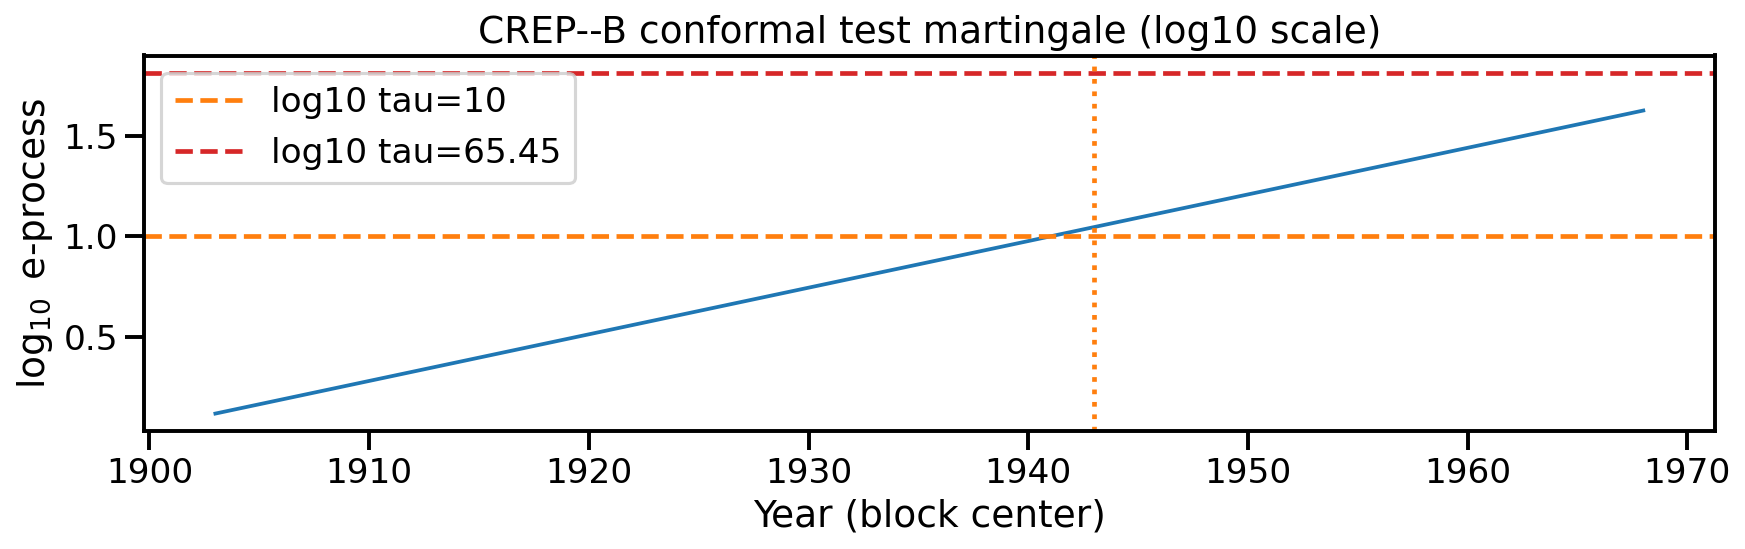


Figures:
 - crep_nile_outputs/figs/nile_cal_blockmax_hist.png
 - crep_nile_outputs/figs/nile_eproc_log.png
 - crep_nile_outputs/figs/nile_pvals_blocks.png
 - crep_nile_outputs/figs/nile_series_split.png
 - crep_nile_outputs/figs/nile_z_all.png
Tables:
 - crep_nile_outputs/tables/crep_nile_detection_summary.tex
 - crep_nile_outputs/tables/crep_nile_epochwise_head.tex

Bundled: crep_nile_outputs/crep_nile_bundle.zip


In [1]:
# ============================================================
# CREP-B on REAL DATA (non-astronomy): Nile River annual flow
# - Non-overlapping blocks
# - Split-conformal block maxima -> valid p's
# - Power p->e, multiply -> conformal test martingale (anytime e-process)
# - Saves AND shows all plots, writes LaTeX tables, bundles zip
# ============================================================

import warnings, os, zipfile
from pathlib import Path
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context("talk")
plt.rcParams["figure.dpi"] = 150

# ---- Try to load real dataset from statsmodels (packaged, no network) ----
try:
    import statsmodels.api as sm
    nile_df = sm.datasets.nile.load_pandas().data  # column 'Nile'
    # The dataset covers 1871-1970 (100 years)
    if "year" in nile_df.columns:
        years = nile_df["year"].to_numpy(dtype=float)
    else:
        years = np.arange(1871, 1871 + len(nile_df), dtype=float)
    flow = nile_df.iloc[:, 0].to_numpy(dtype=float)  # first/only column is flow
except Exception as e:
    raise RuntimeError(
        f"Could not load statsmodels Nile dataset: {e}\n"
        "Please install statsmodels (pip install statsmodels) and re-run."
    )

# ---- Output folders ----
ROOT = Path("crep_nile_outputs")
FIGS = ROOT / "figs"
TABS = ROOT / "tables"
for D in (FIGS, TABS):
    D.mkdir(parents=True, exist_ok=True)

# ---- CREP-B helpers ----
def robust_scale_from_cal(y_cal):
    """Return (mu, sigma) from calibration only using median+MAD; fallback to std."""
    y = np.asarray(y_cal, float)
    mu = np.median(y)
    mad = np.median(np.abs(y - mu))
    sigma = 1.4826 * mad
    if not np.isfinite(sigma) or sigma <= 1e-12:
        s = np.std(y)
        sigma = s if s > 0 else 1.0
    return float(mu), float(sigma)

def standardize_against_cal(y, mu, sigma):
    """z = (y - mu)/sigma with robust (mu,sigma) computed on calibration ONLY."""
    y = np.asarray(y, float)
    return (y - mu) / max(sigma, 1e-12)

def build_block_starts(n, win):
    """Non-overlapping blocks of length win across n samples (drop tail)."""
    if n < win:
        return np.array([], dtype=int)
    return np.arange(0, n - win + 1, win, dtype=int)

def block_centers(x, starts, win):
    return x[starts + win // 2]

def block_stat_maxabs_z(z, starts, win):
    stats = []
    for s in starts:
        z_block = z[s:s+win]
        stats.append(float(np.max(np.abs(z_block))))
    return np.asarray(stats, float)

def split_conformal_pvals(test_stats, cal_stats):
    """Two-sided split-conformal p-values: (1 + #cal >= test)/(m+1)."""
    cal = np.sort(np.asarray(cal_stats, float))
    m = len(cal)
    if m == 0:
        return np.ones_like(test_stats, dtype=float)
    idx_right = np.searchsorted(cal, np.asarray(test_stats, float), side="right")
    ge_counts = m - idx_right
    return (1.0 + ge_counts) / (m + 1.0)

def p_to_e_lambda(p, lam):
    p = np.clip(np.asarray(p, float), 1e-16, 1.0)
    lam = float(lam)
    if not (0.0 < lam < 1.0):
        raise ValueError("lam must be in (0,1)")
    return lam * p ** (lam - 1.0)

def eproc_from_e(evals):
    e = np.asarray(evals, float)
    loge = np.cumsum(np.log(np.maximum(e, 1e-300)))
    return np.exp(loge), loge

def first_crossing(eproc, times, tau):
    e = np.asarray(eproc, float)
    if e.size == 0 or np.all(e < tau):
        return None, None, None
    idx = int(np.argmax(e >= tau))
    return idx, float(times[idx]), float(e[idx])

# ---- 1) Split calibration vs monitoring ----
target = "Nile River annual flow"
n = len(flow)
cal_frac = 0.30
cut = int(np.floor(cal_frac * n))
y_cal = flow[:cut]
t_cal = years[:cut]
y_mon = flow[cut:]
t_mon = years[cut:]

# ---- 2) Baseline from calibration only (robust) ----
mu_cal, sig_cal = robust_scale_from_cal(y_cal)
z_all  = standardize_against_cal(flow, mu_cal, sig_cal)
z_cal  = z_all[:cut]
z_mon  = z_all[cut:]

# ---- 3) Non-overlapping blocks ----
# Annual data → choose a block of 5 years to detect a structural break
win = 5
starts_cal = build_block_starts(len(z_cal), win)
starts_mon = build_block_starts(len(z_mon), win)

tcal_centers  = block_centers(t_cal, starts_cal, win) if starts_cal.size else np.array([], float)
tmon_centers  = block_centers(t_mon, starts_mon, win) if starts_mon.size else np.array([], float)

stat_cal = block_stat_maxabs_z(z_cal, starts_cal, win) if starts_cal.size else np.array([], float)
stat_mon = block_stat_maxabs_z(z_mon, starts_mon, win) if starts_mon.size else np.array([], float)

# ---- 4) Split-conformal p's & e-increments ----
p_mon = split_conformal_pvals(stat_mon, stat_cal)
lam = 0.60
e_inc = p_to_e_lambda(p_mon, lam=lam)
eproc, loge = eproc_from_e(e_inc)

# ---- 5) Thresholds & first crossings ----
tau_demo   = 10.0
tau_strict = 65.45
idx_demo, t_demo, e_demo = first_crossing(eproc, tmon_centers, tau_demo)
idx_strict, t_strict, e_strict = first_crossing(eproc, tmon_centers, tau_strict)

print(f"{target} — CREP-B")
print(f"Calibration years: {t_cal[0]:.0f}–{t_cal[-1]:.0f}  |  Monitoring years: {t_mon[0]:.0f}–{t_mon[-1]:.0f}")
print(f"lam = {lam:.2f}, win = {win} years")
print(f"First crossing @ tau={tau_demo:g}:   {idx_demo, t_demo, e_demo}")
print(f"First crossing @ tau={tau_strict:g}: {idx_strict, t_strict, e_strict}")

# ---- 6) Tables (LaTeX) ----
det_rows = []
det_rows.append([target, "demo", lam, tau_demo, idx_demo, t_demo, e_demo])
det_rows.append([target, "strict", lam, tau_strict, idx_strict, t_strict, e_strict])
det_df  = pd.DataFrame(det_rows, columns=["target","variant","lam","tau","first_cross_index","first_cross_time","e_at_cross"])
with open(TABS / "crep_nile_detection_summary.tex", "w") as f:
    f.write(det_df.to_latex(index=False, float_format="%.4g"))

ep_head = pd.DataFrame({
    "time_center": tmon_centers,
    "block_stat": stat_mon,
    "p_conformal": p_mon,
    "e_lambda": e_inc,
    "loge": loge,
    "eproc": eproc
}).head(30)
with open(TABS / "crep_nile_epochwise_head.tex", "w") as f:
    f.write(ep_head.to_latex(index=False, float_format="%.6g",
                             caption="First 30 monitoring blocks (Nile, CREP--B)."))

# ---- 7) Figures (save AND show) ----

# (F1) Raw series with split
plt.figure(figsize=(12,4.5))
plt.plot(years, flow, lw=1.5, color="tab:blue")
plt.axvspan(years[0], t_cal[-1], color="tab:green", alpha=0.15, label="Calibration")
plt.axvspan(t_mon[0], years[-1], color="tab:blue", alpha=0.08, label="Monitoring")
plt.title(f"{target}: annual flow")
plt.xlabel("Year")
plt.ylabel("Flow (10^8 m^3)")
plt.legend(loc="best")
plt.tight_layout()
plt.savefig(FIGS / "nile_series_split.png")
plt.show()

# (F2) Calibration-vs-monitoring standardized series (z)
plt.figure(figsize=(12,4.5))
plt.plot(years, z_all, lw=1.2, color="k", alpha=0.8)
plt.axhline(0, color="gray", lw=1, ls="--")
plt.axvline(t_mon[0], color="gray", lw=1, ls=":")
plt.title("Standardized residuals vs calibration baseline (median/MAD)")
plt.xlabel("Year")
plt.ylabel("z-score (calibration baseline)")
plt.tight_layout()
plt.savefig(FIGS / "nile_z_all.png")
plt.show()

# (F3) Calibration block maxima histogram
plt.figure(figsize=(7,5))
sns.histplot(stat_cal, bins=12, kde=True, color="tab:green")
plt.title("Calibration block maxima (max |z| in 5-year blocks)")
plt.xlabel("Block statistic")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIGS / "nile_cal_blockmax_hist.png")
plt.show()

# (F4) Conformal p-values per monitoring block
plt.figure(figsize=(12,4))
plt.plot(tmon_centers, p_mon, "o", ms=5, alpha=0.85)
plt.axhline(0.5, color="gray", ls="--", lw=1)
plt.title("Two-sided split-conformal p-values (monitoring blocks)")
plt.xlabel("Year (block center)")
plt.ylabel("p-value")
plt.tight_layout()
plt.savefig(FIGS / "nile_pvals_blocks.png")
plt.show()

# (F5) e-process on log10 scale with thresholds
plt.figure(figsize=(12,4))
plt.plot(tmon_centers, np.log10(eproc + 1e-300), "-", lw=1.8, color="tab:blue")
plt.axhline(np.log10(tau_demo), color="tab:orange", ls="--", label=f"log10 tau={tau_demo:g}")
plt.axhline(np.log10(tau_strict), color="tab:red", ls="--", label=f"log10 tau={tau_strict:g}")
if idx_demo is not None:   plt.axvline(t_demo, color="tab:orange", ls=":")
if idx_strict is not None: plt.axvline(t_strict, color="tab:red",    ls=":")
plt.title("CREP--B conformal test martingale (log10 scale)")
plt.xlabel("Year (block center)")
plt.ylabel(r"$\log_{10}$ e-process")
plt.legend(loc="best")
plt.tight_layout()
plt.savefig(FIGS / "nile_eproc_log.png")
plt.show()

# ---- 8) Bundle everything ----
zip_path = ROOT / "crep_nile_bundle.zip"
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for p in FIGS.glob("*.png"): zf.write(p, arcname=f"figs/{p.name}")
    for p in TABS.glob("*.tex"): zf.write(p, arcname=f"tables/{p.name}")

print("\nFigures:")
for p in sorted(FIGS.glob("*.png")):
    print(" -", p.as_posix())
print("Tables:")
for p in sorted(TABS.glob("*.tex")):
    print(" -", p.as_posix())
print("\nBundled:", zip_path.as_posix())
